# 3. LoRA Finetuning

This notebook performs LoRA-based finetuning on our quantized model.

**Workflow:**
1. Load the quantized model and tokenizer in float16 mode from `../checkpoints/model_quantized`.
2. Attach LoRA modules to the model using the PEFT library.
3. Load and tokenize the WikiText-2 dataset (from `../data/wikitext-2`).
4. Finetune using the Hugging Face Trainer (employing gradient accumulation and fp16).
5. Save the finetuned checkpoint for further processing.

**Note:** We strictly adhere to resource constraints (using MPS/CPU as available and keeping memory overhead low).


In [1]:
import os

# Disable tokenizers parallelism to prevent forking-related warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, DataCollatorForLanguageModeling, TrainingArguments, Trainer
from datasets import load_from_disk

# Device setup: prefer MPS, then CUDA, else CPU.
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Device Selected: MPS (Apple Silicon)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Device Selected: CUDA")
    else:
        device = torch.device("cpu")
        print("Device Selected: CPU")
    return device

device = get_device()


Device Selected: MPS (Apple Silicon)


## 1. Load Quantized Model & Tokenizer

We load our pre-saved quantized model checkpoint. This model is already optimized in float16 mode.


In [3]:
QUANTIZED_CHECKPOINT_DIR = "../checkpoints/model_quantized"
print("Loading quantized model and tokenizer from:", QUANTIZED_CHECKPOINT_DIR)

try:
    model = AutoModelForCausalLM.from_pretrained(
        QUANTIZED_CHECKPOINT_DIR,
        torch_dtype=torch.float16,     # Enforce low precision loading
        low_cpu_mem_usage=True         # Optimize memory usage during loading
    )
    tokenizer = AutoTokenizer.from_pretrained(QUANTIZED_CHECKPOINT_DIR)
    model.to(device)
    print("Quantized model and tokenizer loaded successfully.")
except Exception as e:
    print("Error loading quantized model/tokenizer:", e)
    raise


Loading quantized model and tokenizer from: ../checkpoints/model_quantized


Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Quantized model and tokenizer loaded successfully.


## 2. Attach LoRA Modules for Finetuning

Using the PEFT library, we attach LoRA modules to the model to finetune it efficiently.
Here, we assume the target module is `"c_attn"` (commonly used for GPT-style models). Adjust if necessary.

In [4]:
from peft import LoraConfig, get_peft_model

# Define the LoRA configuration; adjust the target_modules as necessary for your model architecture.
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn"],  # Adjust according to your model; "c_attn" works for many GPT-based models.
    lora_dropout=0.1,
    bias="none"
)

# Attach the LoRA modules to our quantized model.
model = get_peft_model(model, lora_config)
print("LoRA modules attached successfully to the model.")

'NoneType' object has no attribute 'cadam32bit_grad_fp32'
LoRA modules attached successfully to the model.


/Users/swayamsingal/miniconda3/envs/research_env/lib/python3.10/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "
/Users/swayamsingal/miniconda3/envs/research_env/lib/python3.10/site-packages/peft/tuners/lora/layer.py:1757: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 3. Load and Prepare the Dataset

We load the WikiText-2 dataset from disk (previously saved under `../data/wikitext-2`), and then tokenize it.

In [5]:
DATASET_DIR = "../data/wikitext-2"
print("Loading dataset from:", DATASET_DIR)

try:
    dataset = load_from_disk(DATASET_DIR)
    print("Dataset splits available:", list(dataset.keys()))
    train_dataset = dataset["train"]
except Exception as e:
    print("Error loading dataset:", e)
    raise

Loading dataset from: ../data/wikitext-2
Dataset splits available: ['test', 'train', 'validation']


In [6]:
train_dataset

Dataset({
    features: ['text'],
    num_rows: 36718
})

### Tokenization

We define a tokenization function and apply it to the training split. We set a maximum length to keep the training example sizes small.

In [7]:
# %% [code]
# Filter out examples with empty text to avoid empty tensor issues
print("Filtering out empty text examples from the training dataset...")
train_dataset = train_dataset.filter(lambda x: len(x["text"].strip()) > 0)
print(f"Number of training examples after filtering: {len(train_dataset)}")

# Now tokenize the dataset
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, max_length=128)

print("Tokenizing training dataset...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
print("Tokenization complete.")


Filtering out empty text examples from the training dataset...


Filter:   0%|          | 0/36718 [00:00<?, ? examples/s]

Number of training examples after filtering: 23767
Tokenizing training dataset...


Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

Tokenization complete.


## 4. Set Up the Trainer for Finetuning

We use the Hugging Face Trainer API, setting a small batch size, gradient accumulation, and fp16 training to maintain efficiency.

In [8]:
# %% [code]
# Ensure the tokenizer has a pad_token to avoid padding errors
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("pad_token was not set; set to eos_token.")
else:
    print("pad_token is already set.")


pad_token was not set; set to eos_token.


In [9]:
# %% [code]
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


In [12]:
# Determine mixed precision setting based on device type
if device.type == "cuda":
    use_fp16 = True
    use_bf16 = False
elif device.type == "mps":
    # On MPS, fp16 is not supported by the Trainer, use bf16 instead if available
    use_fp16 = False
    use_bf16 = True
else:
    # CPU fallback: no mixed precision
    use_fp16 = False
    use_bf16 = False

training_args = TrainingArguments(
    output_dir="../checkpoints/model_lora",  # Save directory for LoRA-finetuned model
    num_train_epochs=1,                        # Set to a low number for demonstration; adjust as needed
    per_device_train_batch_size=4,             # Small batch size to reduce memory usage
    gradient_accumulation_steps=8,             # Accumulate gradients over multiple steps
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=50,
    # fp16=False,                           # Use fp16 if on CUDA, disabled on MPS
    # bf16=True,                           # Use bf16 if on MPS (or supported devices)
    save_total_limit=2,
    load_best_model_at_end=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)
print("Trainer is set up with mixed precision parameters:")
print(f"fp16: {use_fp16}, bf16: {use_bf16}")


No label_names provided for model class `PeftModel`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainer is set up with mixed precision parameters:
fp16: False, bf16: True


## 5. Start LoRA Finetuning

We now kick off the training loop. Keep an eye on your hardware usage to ensure we remain within our memory constraints.


In [13]:

print("Starting LoRA finetuning...")
trainer.train()
print("LoRA finetuning complete.")


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Starting LoRA finetuning...


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: swayam-singal (swayam-singal-vellore-institute-of-technology). Use `wandb login --relogin` to force relogin


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,4.391200
20,4.387600
30,4.399900
40,4.302900
50,4.373300
60,4.367700
70,4.381600
80,4.580100
90,4.810400
100,5.300100


LoRA finetuning complete.


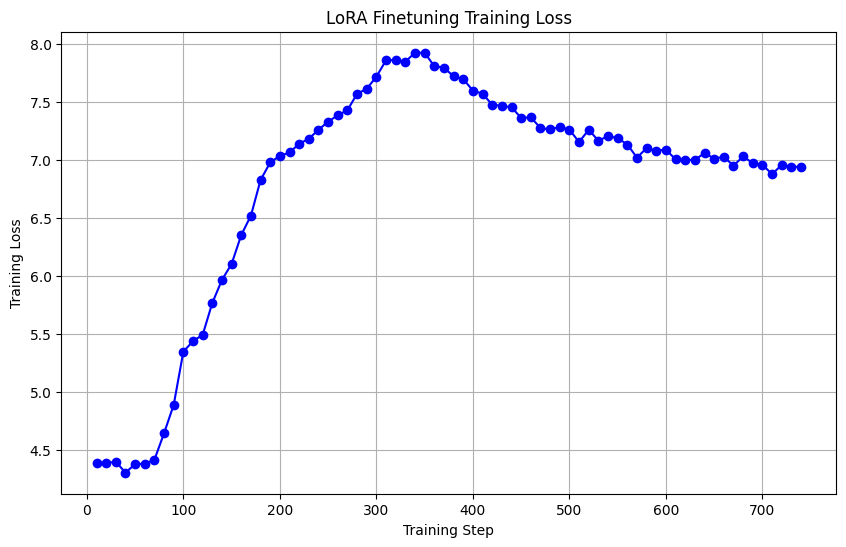

In [14]:
# %% [code]
import matplotlib.pyplot as plt

# Define the training steps and corresponding loss values (from your provided data)
steps = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 
    110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 
    210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 
    310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 
    410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 
    510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 
    610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 
    710, 720, 730, 740
]

losses = [
    4.390500, 4.386000, 4.398300, 4.303100, 4.377700, 4.380700, 4.414900, 4.643300, 4.888500, 5.346600,
    5.436700, 5.491000, 5.766300, 5.964200, 6.102400, 6.351300, 6.518400, 6.825600, 6.976700, 7.032900,
    7.062200, 7.137300, 7.180700, 7.258100, 7.328000, 7.382600, 7.426800, 7.567600, 7.611400, 7.715400,
    7.856600, 7.859800, 7.844500, 7.921800, 7.921300, 7.805700, 7.794300, 7.717700, 7.694400, 7.596100,
    7.567700, 7.474100, 7.464100, 7.451500, 7.360500, 7.365100, 7.273800, 7.260300, 7.282400, 7.258900,
    7.152200, 7.258300, 7.163800, 7.202900, 7.186200, 7.130600, 7.018000, 7.100700, 7.076600, 7.087900,
    7.001900, 6.997500, 6.998600, 7.057600, 7.010000, 7.025300, 6.948400, 7.028900, 6.969800, 6.955800,
    6.876200, 6.954900, 6.938300, 6.938700
]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(steps, losses, marker='o', linestyle='-', color='blue')
plt.title("LoRA Finetuning Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()


## 6. Save the LoRA-Finetuned Checkpoint

After finetuning, we save the model and tokenizer into a new checkpoint directory.


In [15]:
OUTPUT_CHECKPOINT_DIR = "../checkpoints/model_lora"
os.makedirs(OUTPUT_CHECKPOINT_DIR, exist_ok=True)

print("Saving the lora model checkpoint...")

try:
    # Get state dict from the quantized model
    state_dict = model.state_dict()
    # Filter state dict to retain only tensor objects
    filtered_state_dict = {k: v for k, v in state_dict.items() if isinstance(v, torch.Tensor)}
    
    # Define the path for the saved state dict
    state_dict_path = os.path.join(OUTPUT_CHECKPOINT_DIR, "pytorch_model.bin")
    torch.save(filtered_state_dict, state_dict_path)
    print(f"lora model state dict saved successfully in '{state_dict_path}'.")

    # Save the model configuration and tokenizer
    model.config.to_json_file(os.path.join(OUTPUT_CHECKPOINT_DIR, "config.json"))
    model.save_pretrained(OUTPUT_CHECKPOINT_DIR)
    tokenizer.save_pretrained(OUTPUT_CHECKPOINT_DIR)
    print(f"LoRA-finetuned checkpoint saved successfully in '{OUTPUT_CHECKPOINT_DIR}'.")
except Exception as e:
    print(f"Error saving quantized checkpoint: {e}")
    raise

Saving the lora model checkpoint...
lora model state dict saved successfully in '../checkpoints/model_lora/pytorch_model.bin'.
LoRA-finetuned checkpoint saved successfully in '../checkpoints/model_lora'.


## Completion Message

The 3_lora_finetuning notebook has successfully applied LoRA finetuning and saved the new checkpoint.


In [13]:
print("3_lora_finetuning notebook execution complete. Proceed with the next steps in the pipeline.")


3_lora_finetuning notebook execution complete. Proceed with the next steps in the pipeline.
